# Object Detection & Training Own Model

This notebook walks through **how object detection works** from the ground up, then covers every stage of **training a YOLO model** on your own custom dataset (the EU licence-plate dataset already in this repo).

| Stage | What you'll learn |
|---|---|
| 1 | Libraries and tooling |
| 2 | Loading a pre-trained model and running inference |
| 3 | Dataset preparation (YOLO label format) |
| 4 | Data augmentation |
| 5 | Model architecture — freezing backbone, swapping head |
| 6 | Training loop, losses |
| 7 | Evaluation — mAP & IoU |
| 8 | Visualising predictions vs ground-truth |
| 9 | Exporting to ONNX for deployment |

> **Hardware note:** a CUDA GPU speeds up training significantly, but every cell also runs on CPU (slower).


## 1. Import Required Libraries

In [1]:
from pathlib import Path
import random
import time
import warnings
warnings.filterwarnings("ignore")

# ── Import onnxruntime FIRST to avoid the TORCH_LIBRARY "prims" conflict ──────
# onnxruntime must be imported before torch to prevent duplicate namespace
# registration errors when both packages load their torch bindings.
import onnxruntime as ort

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml

import torch
from ultralytics import YOLO

print(f"PyTorch        : {torch.__version__}")
print(f"ONNXRuntime    : {ort.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device   : {device}")


PyTorch        : 2.7.1+cpu
ONNXRuntime    : 1.26.0
CUDA available : False
Using device   : cpu


## 2. Load a Pre-trained Object Detection Model

### How YOLO detection works — conceptually

YOLO ("You Only Look Once") divides the image into an **S × S grid**. Each grid cell predicts:
- **B bounding boxes** — each described by *(x, y, w, h, confidence)*
- **C class probabilities** — one per object class

All predictions happen in a **single forward pass**, making it very fast.

```
Input image
    │
    ▼
Backbone (feature extraction — e.g. CSPDarknet)
    │
    ▼
Neck  (FPN / PAN — multi-scale feature fusion)
    │
    ▼
Head  (predict boxes + classes at 3 scales)
    │
    ▼
NMS  (Non-Maximum Suppression — remove duplicate boxes)
    │
    ▼
Final detections
```

**Non-Maximum Suppression (NMS)** keeps the single best box per object by:
1. Sorting boxes by confidence score.
2. Removing any box whose **IoU** with the best box exceeds a threshold.

$$IoU = \frac{|A \cap B|}{|A \cup B|}$$


In [ ]:
# ── Load base YOLOv8-nano (pretrained on COCO — 80 classes) ───────────────────
BASE_MODEL_PATH = "../models/yolov8n.pt"

base_model = YOLO(BASE_MODEL_PATH)
print("Model loaded:", BASE_MODEL_PATH)
print("Number of classes:", len(base_model.names))
print("Classes sample:", dict(list(base_model.names.items())[:10]))

# Quick model summary (layer count, parameter count)
base_model.info(verbose=False)


Model loaded: yolov8n.pt
Number of classes: 80
Classes sample: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light'}


In [ ]:
# ── Run inference with the base model on one sample image ─────────────────────
DATA_IMAGES = Path("../data-images")
SUPPORTED   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

sample_images = sorted(p for p in DATA_IMAGES.iterdir() if p.suffix.lower() in SUPPORTED)

if not sample_images:
    print("No images found in ../data-images/. Add some JPG/PNG files to try inference.")
else:
    sample = sample_images[0]
    print(f"Running base model on: {sample.name}")
    results = base_model.predict(str(sample), conf=0.25, verbose=False)
    r = results[0]
    print(f"  Detected {len(r.boxes)} object(s):")
    for box in r.boxes:
        cls_id = int(box.cls)
        print(f"    class={base_model.names[cls_id]:15s}  conf={float(box.conf):.2f}  "
              f"xyxy={[round(v,1) for v in box.xyxy[0].tolist()]}")


Running base model on: dsc0226.jpg
  Detected 2 object(s):
    class=car              conf=0.71  xyxy=[166.3, 331.5, 1773.9, 1045.3]
    class=truck            conf=0.27  xyxy=[162.2, 329.6, 1783.0, 1043.4]


## 3. Prepare Dataset for Fine-Tuning

### YOLO label format

Each image has a matching `.txt` file with one row per object:

```
<class_id>  <x_center>  <y_center>  <width>  <height>
```
All values are **normalised to [0, 1]** relative to the image dimensions.

```
Image (640×480)
┌─────────────────────┐
│                     │
│   ┌─────────┐       │  Label row:  0  0.52  0.61  0.18  0.12
│   │ plate   │       │  class=0, cx=52%, cy=61%, w=18%, h=12%
│   └─────────┘       │
└─────────────────────┘
```

The `data.yaml` file tells YOLO where the splits live and what the classes are.


In [ ]:
# ── Inspect the dataset YAML ──────────────────────────────────────────────────
DATASET_YAML = Path("../images-eu/data_fixed.yaml")

with open(DATASET_YAML) as f:
    cfg = yaml.safe_load(f)

print("Dataset config:")
for k, v in cfg.items():
    print(f"  {k}: {v}")


Dataset config:
  names: ['0']
  nc: 1
  roboflow: {'license': 'CC BY 4.0', 'project': 'european-license-plates', 'url': 'https://universe.roboflow.com/patrick-neicu/european-license-plates/dataset/1', 'version': 1, 'workspace': 'patrick-neicu'}
  test: C:\Users\krist\Documents\GitHub\OCR-Research\images-eu\test\images
  train: C:\Users\krist\Documents\GitHub\OCR-Research\images-eu\train\images
  val: C:\Users\krist\Documents\GitHub\OCR-Research\images-eu\valid\images


In [ ]:
# ── Count images and labels per split ────────────────────────────────────────
DATASET_ROOT = Path("../images-eu")

for split in ("train", "valid", "test"):
    img_dir = DATASET_ROOT / split / "images"
    lbl_dir = DATASET_ROOT / split / "labels"
    imgs = list(img_dir.glob("*")) if img_dir.exists() else []
    lbls = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    print(f"{split:6s} → {len(imgs):4d} images,  {len(lbls):4d} label files")

# ── Peek at one label file ────────────────────────────────────────────────────
label_files = sorted((DATASET_ROOT / "train" / "labels").glob("*.txt"))
if label_files:
    print(f"\nSample label ({label_files[0].name}):")
    print(label_files[0].read_text().strip())
    print("\nFormat:  class_id  x_center  y_center  width  height  (all normalised 0–1)")


train  →   32 images,  1018 label files
valid  →   28 images,   291 label files
test   →   13 images,   146 label files

Sample label (d_license_plate_100_jpg.rf.1f1cc70f2344f4beb728597599aa401c.txt):
0 0.4953125 0.5 0.9703125 0.4796875

Format:  class_id  x_center  y_center  width  height  (all normalised 0–1)


## 4. Data Augmentation Pipeline

Augmentation artificially expands your dataset and forces the model to generalise.  
Ultralytics YOLO applies these **automatically during training** — you just set hyperparameters.

| Augmentation | What it does | Typical value |
|---|---|---|
| `fliplr` | Horizontal flip | 0.5 |
| `flipud` | Vertical flip | 0.0 (rare for plates) |
| `hsv_h/s/v` | Hue / saturation / value jitter | 0.015 / 0.7 / 0.4 |
| `degrees` | Random rotation | ±10° |
| `translate` | Random translation | 0.1 |
| `scale` | Random zoom-in/out | 0.5 |
| `mosaic` | Stitch 4 images together | 1.0 |
| `mixup` | Blend two images | 0.0–0.1 |
| `copy_paste` | Paste objects from other images | 0.0–0.1 |

**Mosaic** is especially powerful — it forces the model to detect small objects at different contexts.

Below we manually demonstrate a horizontal flip + brightness jitter so you can see what the augmented images look like.


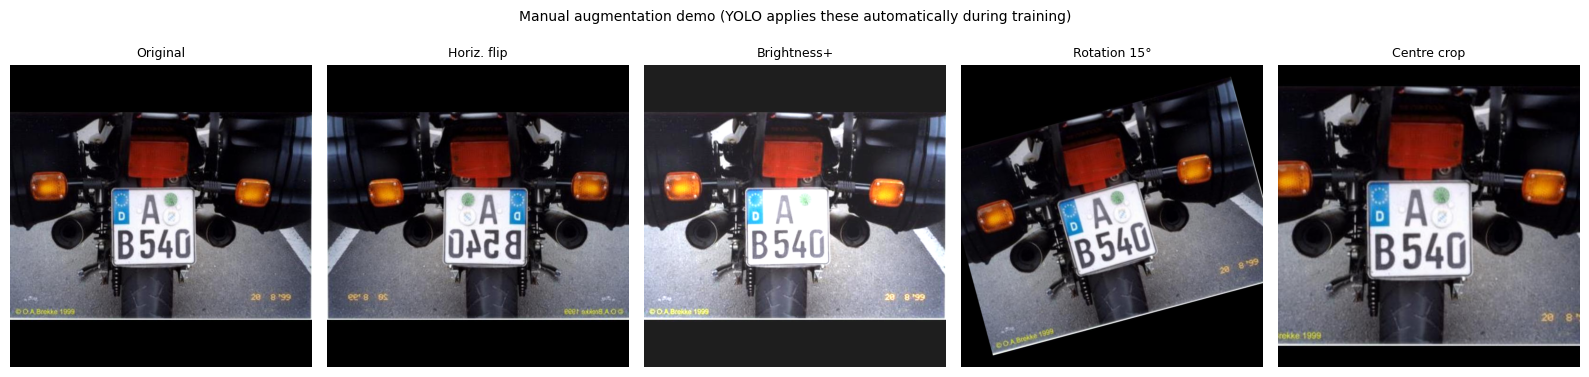

In [6]:
def augment_demo(img: np.ndarray) -> dict:
    """Apply a few common augmentations and return a dict of name → image."""
    results = {"Original": img.copy()}

    # 1. Horizontal flip
    results["Horiz. flip"] = cv2.flip(img, 1)

    # 2. Brightness / contrast jitter (simulates HSV value shift)
    bright = cv2.convertScaleAbs(img, alpha=1.3, beta=30)
    results["Brightness+"] = bright

    # 3. Random rotation ±15°
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle=15, scale=1.0)
    results["Rotation 15°"] = cv2.warpAffine(img, M, (w, h))

    # 4. Random crop (scale = 0.8)
    ch, cw = int(h * 0.8), int(w * 0.8)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    cropped = img[y0:y0+ch, x0:x0+cw]
    results["Centre crop"] = cv2.resize(cropped, (w, h))

    return results


# ── Pick one training image and show augmentations ───────────────────────────
train_imgs = sorted((DATASET_ROOT / "train" / "images").glob("*.jpg"))
if train_imgs:
    raw = cv2.imread(str(train_imgs[0]))
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    aug_imgs = augment_demo(raw)

    fig, axes = plt.subplots(1, len(aug_imgs), figsize=(16, 4))
    for ax, (title, im) in zip(axes, aug_imgs.items()):
        ax.imshow(im)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.suptitle("Manual augmentation demo (YOLO applies these automatically during training)",
                 fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No training images found — skipping augmentation demo.")


## 5. Configure Model for Fine-Tuning

### What changes during fine-tuning?

```
Backbone  ← FROZEN  (keeps general visual features learned on ImageNet/COCO)
   │
Neck      ← can be partially frozen or trained slowly
   │
Head      ← RETRAINED  (outputs re-wired for your N custom classes)
```

- **Frozen backbone** = faster training, less risk of catastrophic forgetting.
- **Lower learning rate** for the backbone if you do unfreeze it.
- Ultralytics handles head replacement automatically — just pass `data=` with your class count.

### Key hyperparameters

| Param | Meaning | Typical fine-tune value |
|---|---|---|
| `epochs` | Training iterations over full dataset | 50–150 |
| `imgsz` | Input resolution | 640 |
| `batch` | Images per gradient step | 16–32 |
| `lr0` | Initial learning rate | 0.001 |
| `lrf` | Final LR as fraction of lr0 | 0.01 |
| `freeze` | Number of backbone layers to freeze | 10 |
| `patience` | Early-stop if no improvement after N epochs | 20 |


In [7]:
# ── Fine-tune configuration ───────────────────────────────────────────────────
FINETUNE_CFG = dict(
    data        = str(DATASET_YAML.resolve()),   # path to data.yaml
    epochs      = 50,                            # increase for better results
    imgsz       = 640,
    batch       = 16,
    lr0         = 0.001,
    lrf         = 0.01,
    freeze      = 10,                            # freeze first 10 backbone layers
    patience    = 20,                            # early stopping
    device      = device,
    project     = "models",
    name        = "plate-finetune-v1",
    exist_ok    = True,                          # overwrite previous run
    # Augmentation overrides (plate-specific tweaks)
    fliplr      = 0.5,
    flipud      = 0.0,   # plates are almost never upside-down
    degrees     = 5.0,
    hsv_s       = 0.5,
    mosaic      = 0.8,
    verbose     = False,
)

print("Fine-tune configuration:")
for k, v in FINETUNE_CFG.items():
    print(f"  {k:12s}: {v}")


Fine-tune configuration:
  data        : C:\Users\krist\Documents\GitHub\Object-Detection-Research\images-eu\data_fixed.yaml
  epochs      : 50
  imgsz       : 640
  batch       : 16
  lr0         : 0.001
  lrf         : 0.01
  freeze      : 10
  patience    : 20
  device      : cpu
  project     : models
  name        : plate-finetune-v1
  exist_ok    : True
  fliplr      : 0.5
  flipud      : 0.0
  degrees     : 5.0
  hsv_s       : 0.5
  mosaic      : 0.8
  verbose     : False


## 6. Train the Model

### The loss function

YOLO optimises a **combined loss** over every grid cell:

$$\mathcal{L} = \mathcal{L}_{\text{box}} + \mathcal{L}_{\text{obj}} + \mathcal{L}_{\text{cls}}$$

| Term | Measures | Formula |
|---|---|---|
| $\mathcal{L}_{\text{box}}$ | Box regression quality | CIoU loss between predicted and GT box |
| $\mathcal{L}_{\text{obj}}$ | Objectness (is there *anything* here?) | BCE with logits |
| $\mathcal{L}_{\text{cls}}$ | Class prediction | BCE per class |

**CIoU** (Complete IoU) penalises not just overlap but also centre distance and aspect-ratio mismatch — making it much more informative than plain MSE on coordinates.

> **Note:** The cell below actually trains the model. On CPU this will be slow (~10–30 min for 50 epochs).  
> If you only want to inspect the pipeline without waiting, set `epochs=1` or skip to Section 7 which uses the pre-trained model already in the repo.


In [8]:
# ── Start training ────────────────────────────────────────────────────────────
# Re-load base weights before training so each run is reproducible.
train_model = YOLO("yolov8n.pt")

t0 = time.time()
train_results = train_model.train(**FINETUNE_CFG)
elapsed = time.time() - t0

print(f"\nTraining finished in {elapsed/60:.1f} min")
print(f"Best weights saved to: {train_results.save_dir}/weights/best.pt")


New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.7 torch-2.7.1+cpu CPU (AMD Ryzen 7 PRO 7840U w/ Radeon 780M Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\krist\Documents\GitHub\Object-Detection-Research\images-eu\data_fixed.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

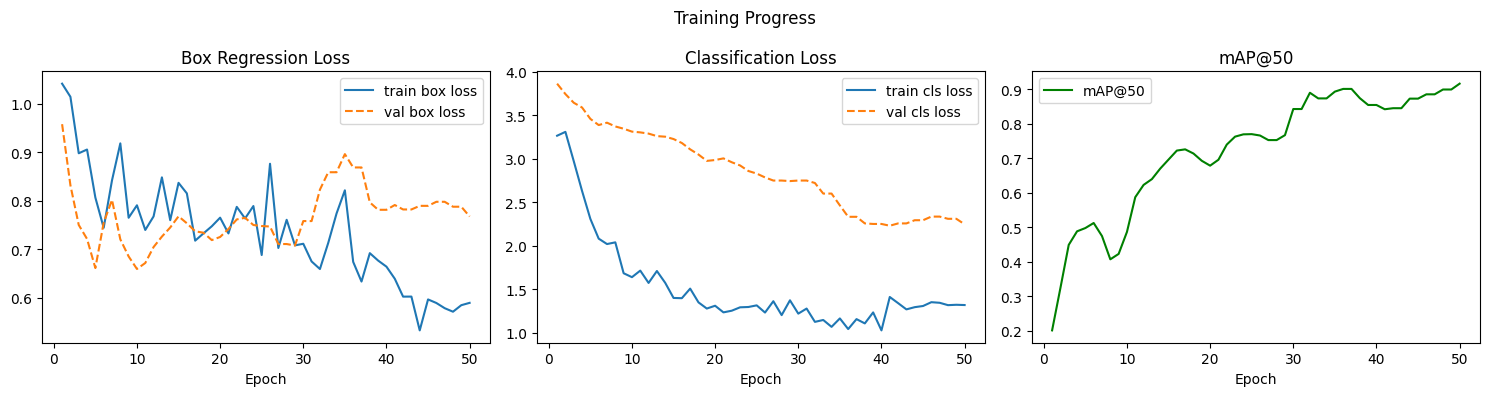

In [9]:
# ── Plot training curves (loss + mAP over epochs) ─────────────────────────────
results_csv = Path(train_results.save_dir) / "results.csv"

if results_csv.exists():
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # strip whitespace from column names

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Box loss
    axes[0].plot(df["epoch"], df["train/box_loss"], label="train box loss")
    if "val/box_loss" in df.columns:
        axes[0].plot(df["epoch"], df["val/box_loss"],  label="val box loss",  linestyle="--")
    axes[0].set_title("Box Regression Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    # Cls loss
    axes[1].plot(df["epoch"], df["train/cls_loss"], label="train cls loss")
    if "val/cls_loss" in df.columns:
        axes[1].plot(df["epoch"], df["val/cls_loss"],  label="val cls loss",  linestyle="--")
    axes[1].set_title("Classification Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    # mAP50
    if "metrics/mAP50(B)" in df.columns:
        axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50", color="green")
        axes[2].set_title("mAP@50"); axes[2].set_xlabel("Epoch"); axes[2].legend()
    else:
        axes[2].set_title("mAP (not available)"); axes[2].axis("off")

    plt.suptitle("Training Progress", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("results.csv not found — run the training cell first.")


## 7. Evaluate Model Performance

### Key metrics explained

**Precision** — of all the boxes the model predicted, how many were correct?

$$Precision = \frac{TP}{TP + FP}$$

**Recall** — of all the ground-truth objects, how many did the model find?

$$Recall = \frac{TP}{TP + FN}$$

**Average Precision (AP)** — area under the Precision–Recall curve for one class.

**mAP\@50** — mean AP across all classes at IoU threshold 0.5.  
**mAP\@50:95** — mean AP averaged over IoU thresholds from 0.5 to 0.95 (stricter, used in COCO benchmarks).

| Score | Interpretation |
|---|---|
| mAP@50 > 0.9 | Excellent for a single-class detector |
| mAP@50 0.7–0.9 | Good |
| mAP@50 < 0.5 | Needs more data / training |


In [ ]:
# ── Evaluate the fine-tuned model on the validation split ─────────────────────
# Falls back to the repo's pre-trained ONNX if training hasn't been run yet.
best_pt = Path("../models/plate-finetune-v1/weights/best.pt")
eval_model_path = str(best_pt) if best_pt.exists() else "license-plate-finetune-v1n.onnx"

print(f"Evaluating: {eval_model_path}")
eval_model = YOLO(eval_model_path)

val_results = eval_model.val(
    data   = str(DATASET_YAML.resolve()),
    split  = "val",
    device = device,
    verbose= True,
)


Evaluating: license-plate-finetune-v1n.onnx
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Ultralytics 8.4.41  Python-3.13.7 torch-2.7.1+cpu CPU (AMD Ryzen 7 PRO 7840U w/ Radeon 780M Graphics)
Loading license-plate-finetune-v1n.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
val: Fast image access  (ping: 0.00.0 ms, read: 265.973.6 MB/s, size: 32.7 KB)
val: Scanning C:\Users\krist\Documents\GitHub\OCR-Research\images-eu\valid\labels.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 9.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8it/s 1.1s2.1s
                   all         28         28        0.9          1      0.986      0.582
Speed: 0.7ms preprocess, 33.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved 

In [11]:
# ── Manual IoU calculation helper ─────────────────────────────────────────────
def compute_iou(boxA: list, boxB: list) -> float:
    """
    Compute IoU between two boxes in [x1, y1, x2, y2] format.

        IoU = |A ∩ B| / |A ∪ B|
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter

    return inter / union if union > 0 else 0.0


# Quick demo
pred_box = [100, 150, 300, 250]   # [x1, y1, x2, y2]
gt_box   = [120, 160, 310, 260]

iou = compute_iou(pred_box, gt_box)
print(f"Predicted box : {pred_box}")
print(f"Ground-truth  : {gt_box}")
print(f"IoU           : {iou:.4f}  ({'MATCH' if iou >= 0.5 else 'MISS'} at threshold 0.5)")


Predicted box : [100, 150, 300, 250]
Ground-truth  : [120, 160, 310, 260]
IoU           : 0.7105  (MATCH at threshold 0.5)


## 8. Visualise Detection Results

We compare:
- **Green box** — ground-truth label from the dataset
- **Red box** — model prediction

A good model should have highly overlapping green and red boxes (high IoU).


Loading license-plate-finetune-v1n.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider


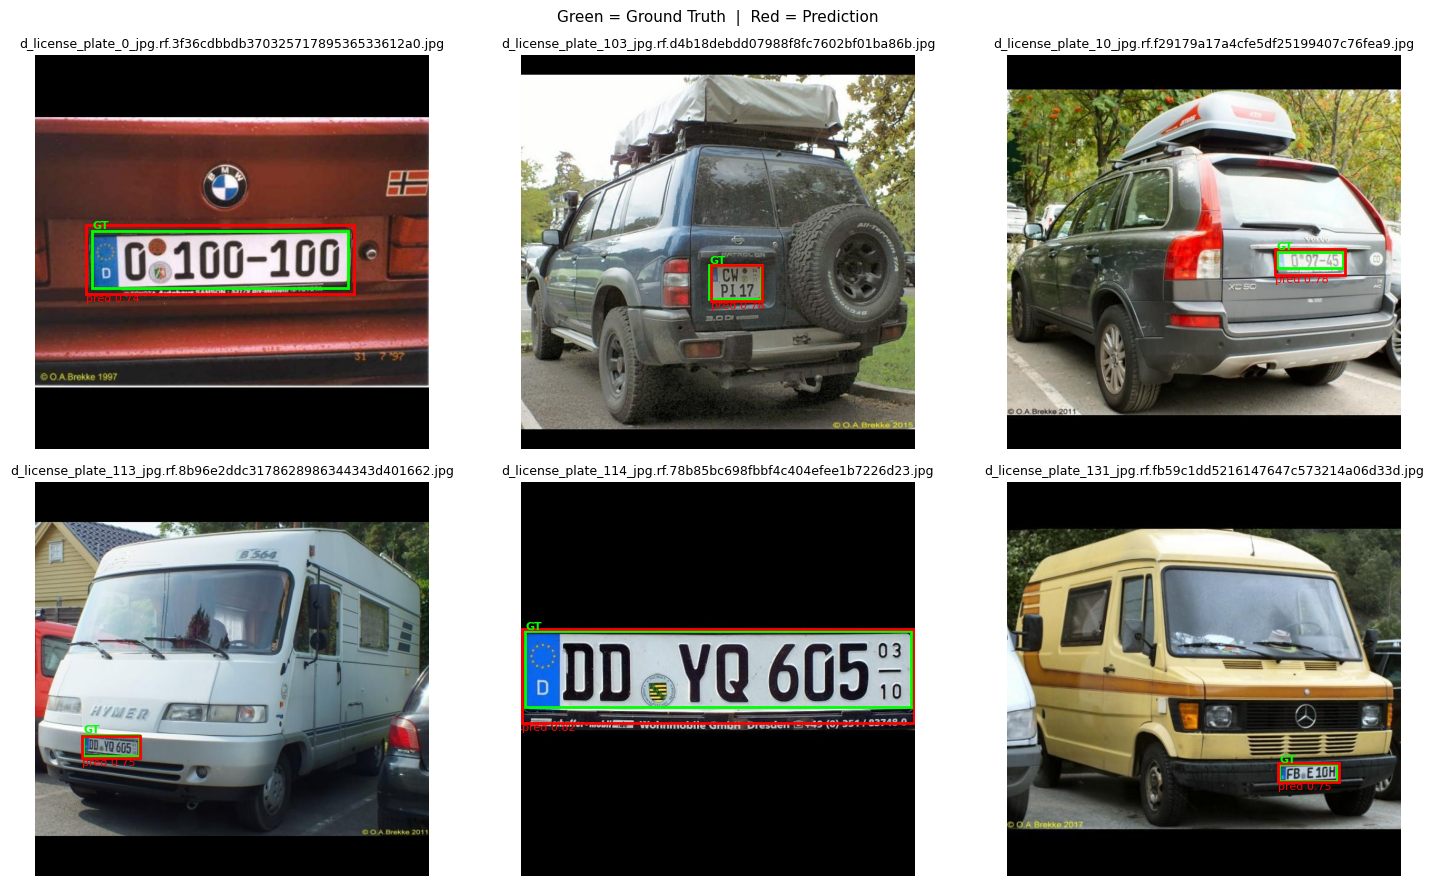

In [12]:
def yolo_label_to_xyxy(label_path: Path, img_w: int, img_h: int) -> list:
    """Parse a YOLO label file and return list of [x1,y1,x2,y2] boxes."""
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text().strip().splitlines():
        parts = list(map(float, line.split()))
        if len(parts) < 5:
            continue
        _, cx, cy, w, h = parts[:5]
        x1 = int((cx - w / 2) * img_w)
        y1 = int((cy - h / 2) * img_h)
        x2 = int((cx + w / 2) * img_w)
        y2 = int((cy + h / 2) * img_h)
        boxes.append([x1, y1, x2, y2])
    return boxes


def visualise_predictions(model, img_path: Path, label_path: Path,
                           conf: float = 0.25, ax=None):
    """Draw GT (green) and predicted (red) boxes side by side."""
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    gt_boxes   = yolo_label_to_xyxy(label_path, w, h)
    pred_res   = model.predict(str(img_path), conf=conf, verbose=False)[0]

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(8, 5))

    ax.imshow(img_rgb)
    for box in gt_boxes:
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                  linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(box[0], box[1]-4, "GT", color="lime", fontsize=8, fontweight="bold")

    for box in pred_res.boxes:
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        conf_val = float(box.conf)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y2+12, f"pred {conf_val:.2f}", color="red", fontsize=8)

    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")


# ── Show predictions on up to 6 validation images ────────────────────────────
val_img_dir = DATASET_ROOT / "valid" / "images"
val_lbl_dir = DATASET_ROOT / "valid" / "labels"

val_imgs = sorted(p for p in val_img_dir.glob("*.jpg") if p.exists())[:6]

if val_imgs:
    n = len(val_imgs)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9)) if n > 3 else plt.subplots(1, n, figsize=(5*n, 5))
    axes_flat = np.array(axes).flatten()

    for ax, img_p in zip(axes_flat, val_imgs):
        lbl_p = val_lbl_dir / img_p.with_suffix(".txt").name
        visualise_predictions(eval_model, img_p, lbl_p, conf=0.25, ax=ax)

    for ax in axes_flat[len(val_imgs):]:
        ax.axis("off")

    plt.suptitle("Green = Ground Truth  |  Red = Prediction", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No validation images found.")


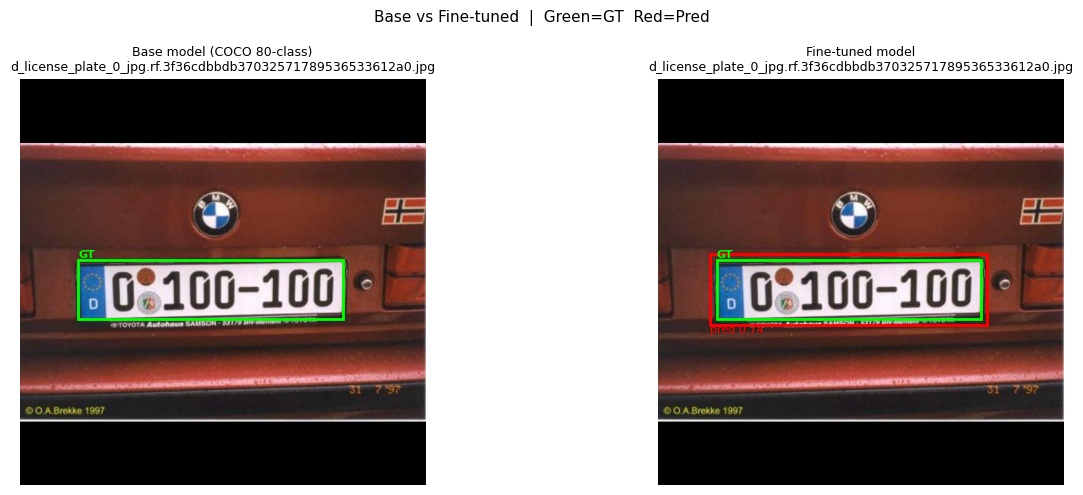

In [13]:
# ── Side-by-side: base COCO model vs fine-tuned model ─────────────────────────
if val_imgs:
    sample = val_imgs[0]
    lbl_p  = val_lbl_dir / sample.with_suffix(".txt").name

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    visualise_predictions(base_model,  sample, lbl_p, conf=0.25, ax=ax1)
    ax1.set_title(f"Base model (COCO 80-class)\n{sample.name}", fontsize=9)

    visualise_predictions(eval_model, sample, lbl_p, conf=0.25, ax=ax2)
    ax2.set_title(f"Fine-tuned model\n{sample.name}", fontsize=9)

    plt.suptitle("Base vs Fine-tuned  |  Green=GT  Red=Pred", fontsize=11)
    plt.tight_layout()
    plt.show()


## 9. Export Fine-Tuned Model

### Available export formats

| Format | Use case |
|---|---|
| **ONNX** | Cross-platform, runs on CPU/GPU, usable from Python, C++, Java |
| **TorchScript** | Pure PyTorch deployment, mobile |
| **TensorRT** | NVIDIA GPU inference (fastest on GPU) |
| **CoreML** | Apple devices |
| **OpenVINO** | Intel hardware |

ONNX is the most portable choice for a web app or REST API (like the `app.py` in this repo).


In [14]:
# ── Export to ONNX ────────────────────────────────────────────────────────────
# Only export if training ran and produced best.pt.
if best_pt.exists():
    export_model = YOLO(str(best_pt))
    onnx_path = export_model.export(
        format  = "onnx",
        imgsz   = 640,
        opset   = 12,        # broad compatibility
        simplify= True,      # graph simplification
        dynamic = False,     # fixed input shape
    )
    print(f"ONNX model saved to: {onnx_path}")
    print(f"File size: {Path(onnx_path).stat().st_size / 1e6:.2f} MB")
else:
    print("No best.pt found — skipping export.")
    print("Run the training cell (Section 6) first, or the repo already includes:")
    print("  license-plate-finetune-v1n.onnx")


No best.pt found — skipping export.
Run the training cell (Section 6) first, or the repo already includes:
  license-plate-finetune-v1n.onnx


In [ ]:
# ── Verify the exported ONNX model runs correctly ─────────────────────────────
# ort is already imported in cell 1 — no re-import needed.
onnx_file = Path("../models/license-plate-finetune-v1n.onnx")   # use the repo's existing model

if onnx_file.exists():
    sess = ort.InferenceSession(str(onnx_file), providers=["CPUExecutionProvider"])
    inp  = sess.get_inputs()[0]
    out  = sess.get_outputs()[0]
    print(f"ONNX Runtime version : {ort.__version__}")
    print(f"Input  name={inp.name}  shape={inp.shape}  dtype={inp.type}")
    print(f"Output name={out.name}  shape={out.shape}  dtype={out.type}")
    print("\nModel is valid and ready for deployment.")
else:
    print(f"{onnx_file} not found.")


ONNX Runtime version : 1.26.0
Input  name=images  shape=['batch', 3, 'height', 'width']  dtype=tensor(float)
Output name=output0  shape=['batch', 5, '(floor(floor(floor(height/2 - 1/2)/2)/2) + 1)*(floor(floor(floor(width/2 - 1/2)/2)/2) + 1) + (floor(floor(floor(floor(height/2 - 1/2)/2)/2)/2) + 1)*(floor(floor(floor(floor(width/2 - 1/2)/2)/2)/2) + 1) + (floor(floor(floor(floor(floor(height/2 - 1/2)/2)/2)/2)/2) + 1)*(floor(floor(floor(floor(floor(width/2 - 1/2)/2)/2)/2)/2) + 1)']  dtype=tensor(float)

Model is valid and ready for deployment.
